In [191]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder
import torch
import sys
sys.path.append("..")
import SGLN
from SGLN import LassoNetRegressor
from scipy.io import loadmat
from pandas import Series
from sklearn.linear_model import Lasso

In [192]:
#加载数据
data = loadmat('../data/side_information_fmnist.mat')
X = data['X']
y = data['y'].T.flatten()  
y = Series(y.astype(np.uint8))

data = []
for i in range(10):
    filter = y == i
    data.append(X[filter])

sample_num = 5
X_train = []
for i in range(0, 10):
     X_train += list(data[i])[0 : sample_num]
X_train = np.array(X_train)
y_train = data[0][0]
X_train = X_train.T

In [193]:
# 分组信息
Groups = []

for i in range(10):
     group = np.arange(start=i*sample_num, stop = (i+1)*sample_num, step=1)
     Groups.append(group)
Groups

[array([0, 1, 2, 3, 4]),
 array([5, 6, 7, 8, 9]),
 array([10, 11, 12, 13, 14]),
 array([15, 16, 17, 18, 19]),
 array([20, 21, 22, 23, 24]),
 array([25, 26, 27, 28, 29]),
 array([30, 31, 32, 33, 34]),
 array([35, 36, 37, 38, 39]),
 array([40, 41, 42, 43, 44]),
 array([45, 46, 47, 48, 49])]

In [194]:
# SGLN
fig_name = "SGLN"
model = SGLN.LassoNetRegressor(
    hidden_dims=(1000,),
    #n_iters=(3000, 500),   # 控制epochs
    lambda_start=1,
    path_multiplier=1.02,   # 控制Lambda_1变化趋势
    alpha=0.5,
    verbose=True,
    #patience=(100, 5)
)
# print(X_train)
path = model.path(X_train, y_train, Groups = Groups)

Initialized dense model
117 epochs, val_objective 2.47e-04, val_loss 2.47e-04, regularization 0.00e+00, l2_regularization 3.03e-01
-------------------------- 1 --------------------------
Lambda_ = 1.00, selected 50 features 
100 epochs, val_objective 1.25e+00, val_loss 2.83e-04, regularization 1.25e+00, l2_regularization 2.98e-01
-------------------------- 2 --------------------------
Lambda_ = 1.02, selected 50 features 
100 epochs, val_objective 5.96e-01, val_loss 2.96e-04, regularization 5.95e-01, l2_regularization 2.88e-01
-------------------------- 3 --------------------------
Lambda_ = 1.04, selected 50 features 
35 epochs, val_objective 5.59e-01, val_loss 5.71e-04, regularization 5.59e-01, l2_regularization 2.85e-01
-------------------------- 4 --------------------------
Lambda_ = 1.06, selected 50 features 
10 epochs, val_objective 5.69e-01, val_loss 6.09e-04, regularization 5.69e-01, l2_regularization 2.85e-01
-------------------------- 5 --------------------------
Lambda_ = 1

SGLN: 31


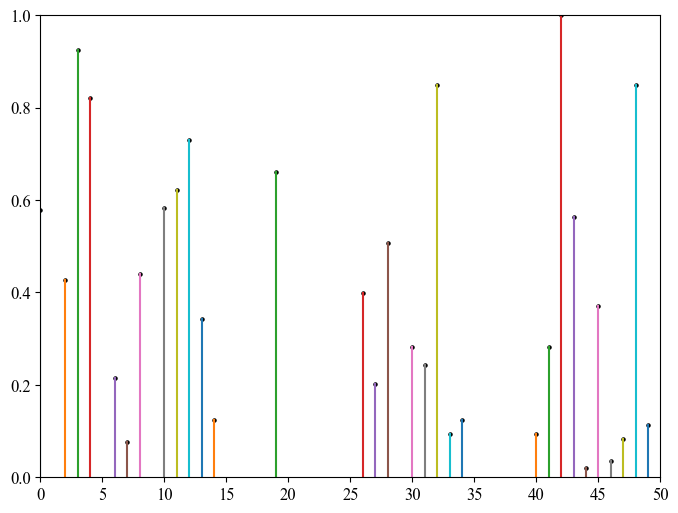

In [195]:
# 绘制测试数据的散点图
from matplotlib.pyplot import MultipleLocator
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

index = -2
weight = abs(np.array(path[index].state_dict['skip.weight'][0]))
importances = weight / sum(weight)
num = np.count_nonzero(importances)
print(str(fig_name) + ": " + str(num))


x=[]
y=[]


df = importances / importances.max()


# df = (importances - importances.min()) / (importances.max() - importances.min())
for i in range(len(df)):
    if df[i] != 0:
        yi = [df[i], -0.15]
        y.append(yi)
        xi = [i,i]
        x.append(xi)

config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}

rcParams.update(config)
plt.figure(dpi=100, figsize=(8, 6))

rng = np.random.RandomState(0)
colors = rng.rand(len(df))  # 随机产生50个用于颜色映射的数值
for i in range(len(x)):
    plt.scatter(x[i], y[i], color='black', s=5)
    plt.plot(x[i], y[i])


# 设置x轴刻度
x_major_locator = MultipleLocator(sample_num)
ax = plt.gca()
ax.xaxis.set_major_locator(x_major_locator)

plt.xlim(0, 50)
plt.ylim(df.min(), df.max())

# plt.title("The feature importance of the picture '0'")
# plt.title(fig_name + ": Select " + str(num) + " features")
# plt.savefig("figures/" + fig_name + ".pdf", bbox_inches='tight')
plt.show()

In [196]:

# sample_num = 5
# matrix = []

# #训练
# print("########## Training Start ##########")
# classify_weight = []
# for k, y in enumerate(y_train):
#     x = X_train
#     x[:, k] = 0
#     model = LassoNetRegressor(
#         hidden_dims=(100,),
#         #n_iters=(3000, 500),   # 控制epochs
#         path_multiplier=1.05,   # 控制Lambda_1变化趋势
#         lambda_start=1,
#         alpha=0.5,
#         verbose=False,   # 决定要不要输出log信息
#     )
#     path = model.path(x, y, Groups = Groups)
#     weight = path[-2].state_dict["skip.weight"]
#     importances = np.linalg.norm(weight, ord=2, axis=0)
#     total = sum(importances)
#     new_coff = [round(num / total, 3) for num in importances ]
#     print(str(k) + " finished")
#     print(new_coff)
#     matrix.append(new_coff)
# print("########## Training End ##########")

# matrix = np.array(matrix)

In [197]:
# # 训练
# matrix = []
# for k, y in enumerate(y_train):
#     x = X_train
#     x[:, k] = 0
#     print(x)
#     lasso = Lasso(alpha=0)
#     lasso.fit(x, y)
#     importances = abs(lasso.coef_)
#     total = sum(importances)
#     new_coff = [round(num / total, 3) for num in importances ]
#     print(str(k) + "   finished")
#     print(new_coff)
#     matrix.append(new_coff)
# matrix = np.array(matrix)
# matrix[0] = matrix[10]

In [198]:
# 定义关联关系的邻接矩阵
# adjacency_matrix = matrix

In [199]:
# # 创建带权无向图
# G = nx.Graph()

# # 添加节点
# num_nodes = adjacency_matrix.shape[0]
# G.add_nodes_from(range(num_nodes))

# # 添加带权边
# for i in range(num_nodes):
#     for j in range(i+1, num_nodes):
#         if adjacency_matrix[i, j] != 0:
#             G.add_edge(i, j, weight=adjacency_matrix[i, j])

In [200]:
# # 绘制网络图
# pos = nx.spring_layout(G)  # 选择布局算法

# # 根据边的权重设置连线的粗细
# edge_widths = [2 * G[u][v]['weight'] for u, v in G.edges()]

# # 绘制连线
# nx.draw_networkx_edges(G, pos, width=edge_widths)

# # 绘制节点和节点标签
# nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
# nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# plt.axis('off')  # 关闭坐标轴
# plt.savefig('figures/network30_lasso.pdf', bbox_inches='tight')